In [1]:
%load_ext autoreload
%autoreload 2

In [41]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from time import time
import os
from dataclasses import replace
from RaTag.core.datatypes import Run, SetPmt, S2Areas, Waveform
from RaTag.core.config import TimingConfig, IntegrationConfig, FitConfig
from RaTag.core.wfm2read_fast import wfm2read
from RaTag.core.paths import get_output_root
from RaTag.waveform.preprocessing import subtract_pedestal, moving_average, threshold_clip
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.thgem_tpc.drift_workflow import map_drift_physics

from RaTag.thgem_tpc.recoil_workflow import (map_recoil_integration, resolve_set_recoils,
                                             find_s2,
                                             _check_s2_clipping, _check_area_bounds,
                                            _integrate_s2_areas, _find_left_boundary)
from RaTag.thgem_tpc.diagnostics import plot_s2_diagnostic
from RaTag.io.file_ops import load_yaml, iter_waveforms
from RaTag.io import file_ops
from RaTag.plotting import plot_timing_histograms, plot_waveform

from scipy.ndimage import maximum_filter1d
%matplotlib inline

In [3]:
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run43_analysis.yaml'
config = load_yaml(config_path)
time_config_dict = config['preparation']
time_config = TimingConfig(**time_config_dict)

run = bootstrap_from_config(config_path)
run = map_drift_physics(run)

Found 9 directories in RUN43_EL25kVcm
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0120_Anode1120 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0188_Anode1188 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0288_Anode1288 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0480_Anode1480 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0576_Anode1576 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0672_Anode1672 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0768_Anode1768 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0864_Anode1864 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0960_Anode1960 with 200 waveforms.
  → Bootstrapped 9 PMT Sets and 9 Alpha Sets. (Multi-Isotope: True)


In [38]:
set0 = run.sets[0]
set2 = run.sets[2]

In [125]:
time_config = replace(time_config, s2_v_min=10)

In [128]:
set0 = resolve_set_recoils(set0, max_frames=None, config=time_config, force=True)

  Iterating FieldScan_Gate0120_Anode1120: 200/200 (100.0%) | ETA: 00:00   
  ✓ FieldScan_Gate0120_Anode1120: Computed 'n_areas_recoil' and stored metadata


  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz


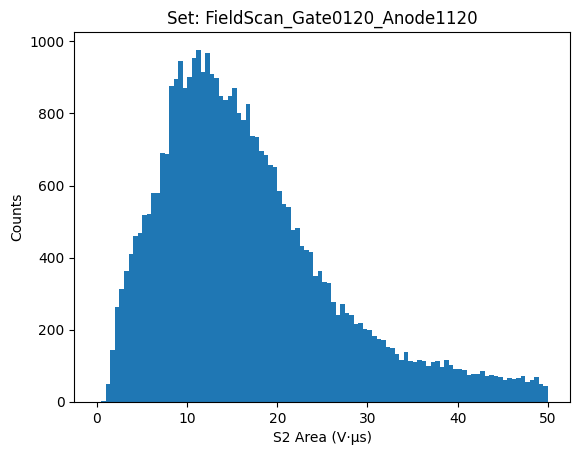

In [130]:
file = file_ops.load_npz_arrays(set0, signal_type='s2_areas', )
# stats_dict = file['stats']
s2_areas_hard = file['s2_areas']
# print(stats_dict)
plt.hist(s2_areas_hard, bins=100, range=(0, 50));
plt.gca().set(xlabel='S2 Area (V·µs)', ylabel='Counts', title='Set: {}'.format(set0.name));

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0288_Anode1288_s2_areas.npz
{'total': 197400, 'pass_clip': 189807, 'pass_left': 153809, 'pass_right': 124136, 'pass_area': 0, 'fallback_right_bound': 0, 'accepted': 74490}


array([44.43897777,  8.08518872,  2.5834945 , ..., 14.00087096,
        1.02362644,  3.17423533])

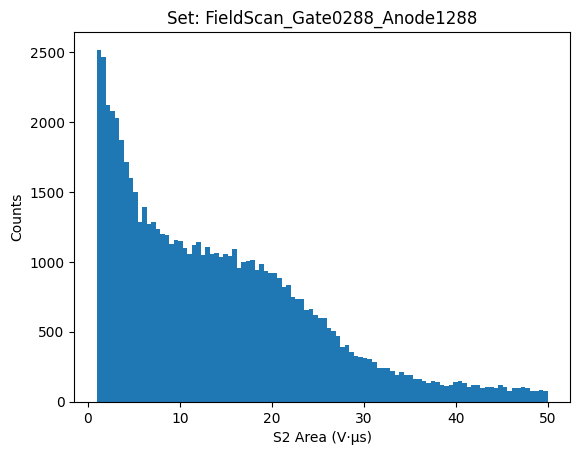

In [40]:
file = file_ops.load_npz_arrays(set2, signal_type='s2_areas', )
stats_dict = file['stats']
s2_areas = file['s2_areas']
print(stats_dict)
plt.hist(s2_areas, bins=100, range=(1, 50));
plt.gca().set(xlabel='S2 Area (V·µs)', ylabel='Counts', title='Set: {}'.format(set2.name));
s2_areas

In [19]:
file_idx = 0
wf = next(iter_waveforms(set0, max_files=1, show_progress=True))

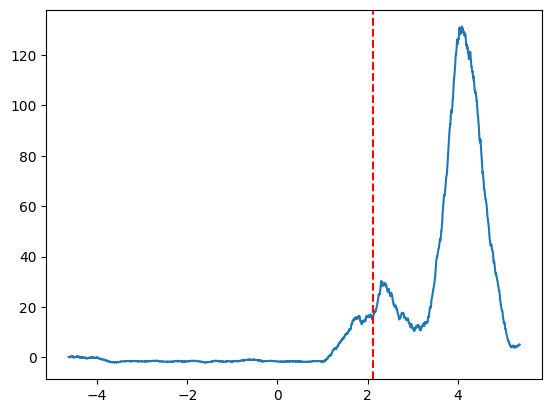

In [37]:
t_s2_min = -1.5 + set0.time_drift #* time_config.s2_margin
frame_idx += 1
# wf = next(iter_waveforms(set0, max_files=1, show_progress=True))
wf_smooth = moving_average(wf, window=time_config.s2_window_ma)
wf_sub = subtract_pedestal(wf_smooth)
v_sum = np.sum(wf_sub.v[120:130, :], axis=0)
wf_sum = replace(wf_sub, v=v_sum[:, np.newaxis])

plt.plot(wf_sum.t, wf_sum.v, label='S2 Waveform')

# plot_waveform(wf_sum, )
plt.axvline(t_s2_min, color='r', linestyle='--', label='S2 Min Time')

In [188]:
time_config.s2_fraction_right

0.01

In [181]:
frame_idx = 0

In [18]:
file_idx = 0
wf = next(iter_waveforms(set0, max_files=1, show_progress=True))

In [386]:
def_idx = 0

In [581]:
time_config = replace(time_config, s2_v_min=1, s2_fraction_left = 0.02, s2_fraction_right = 0.02)

# Diagnostic

In [51]:
wf.source

'/Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN43_EL25kVcm/FieldScan_Gate0120_Anode1120/RUN43_Gate0120_Anode1120_20260726-163141_Batch001_CH3.wfm'

In [98]:
time_config = replace(time_config, s2_v_min=5)

In [69]:
results_s2 = find_s2(wf, config=time_config, t_start_s2=t_s2_min)

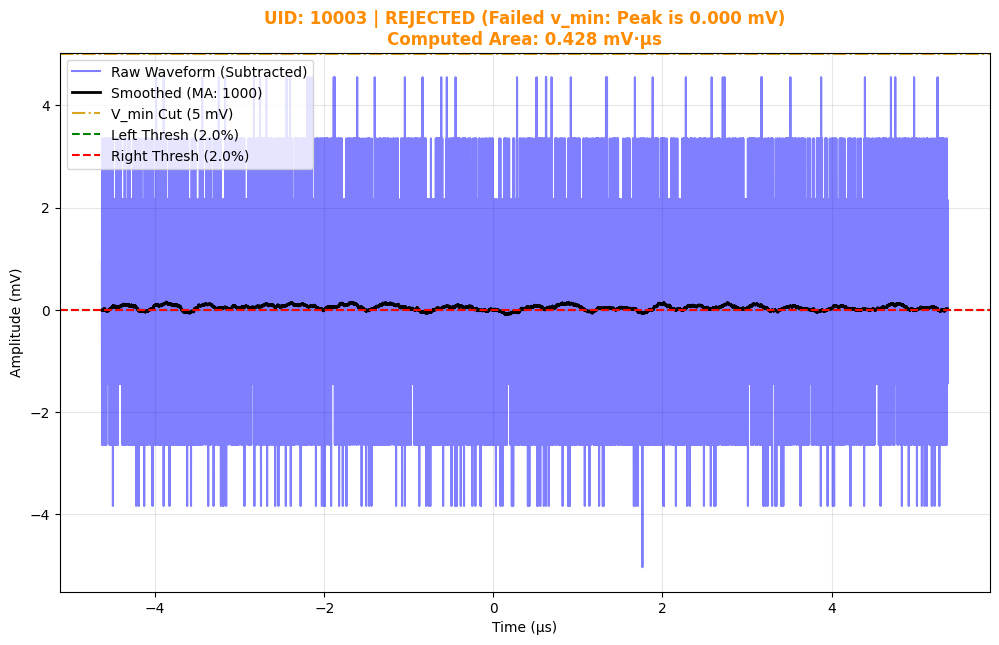

In [99]:
frame_idx += 1
plot_s2_diagnostic(wf, results_s2, config=time_config, frame_idx=frame_idx, )

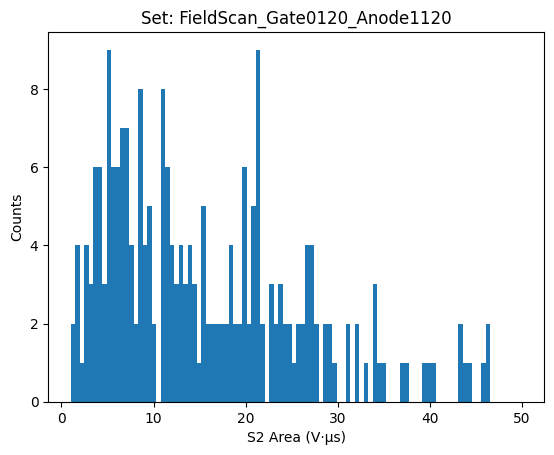

In [89]:
plt.hist(results_s2['s2_areas'], bins=100, range=(1, 50));
plt.gca().set(xlabel='S2 Area (V·µs)', ylabel='Counts', title='Set: {}'.format(set0.name));

In [93]:
mask_small = np.where(results_s2['s2_areas'] < 3)[0]
uids_small = results_s2['uids'][mask_small]

In [ ]:
uids_fail = results_s2['n_minus_one_uids']


In [108]:
frame_idx = 0

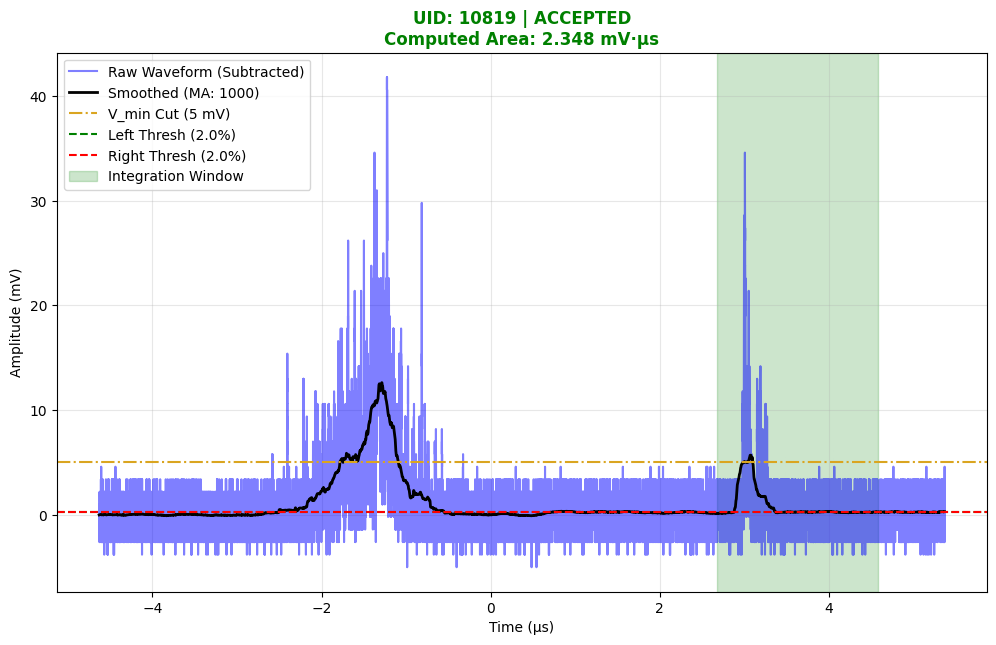

In [116]:
frame_idx += 1
# wf, frame = file_ops.load_waveform_by_uid(set0, uids_fail[frame_idx])
wf, frame = file_ops.load_waveform_by_uid(set0, uids_small[frame_idx])

plot_s2_diagnostic(wf, results_s2, config=time_config, frame_idx=frame, )